<a href="https://colab.research.google.com/github/ahmadjan0123/Machine-Learning/blob/main/Credit_card_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [27]:
df = pd.read_csv('creditcard.csv')

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [ ]:
df.describe()

In [ ]:
df.dtypes()

In [28]:
sns.countplot(df['Class'])

KeyboardInterrupt: 

Error in callback <function _draw_all_if_interactive at 0x7d017a25d120> (for post_execute):


KeyboardInterrupt: 

Error in callback <function flush_figures at 0x7d017a22e660> (for post_execute):


KeyboardInterrupt: 

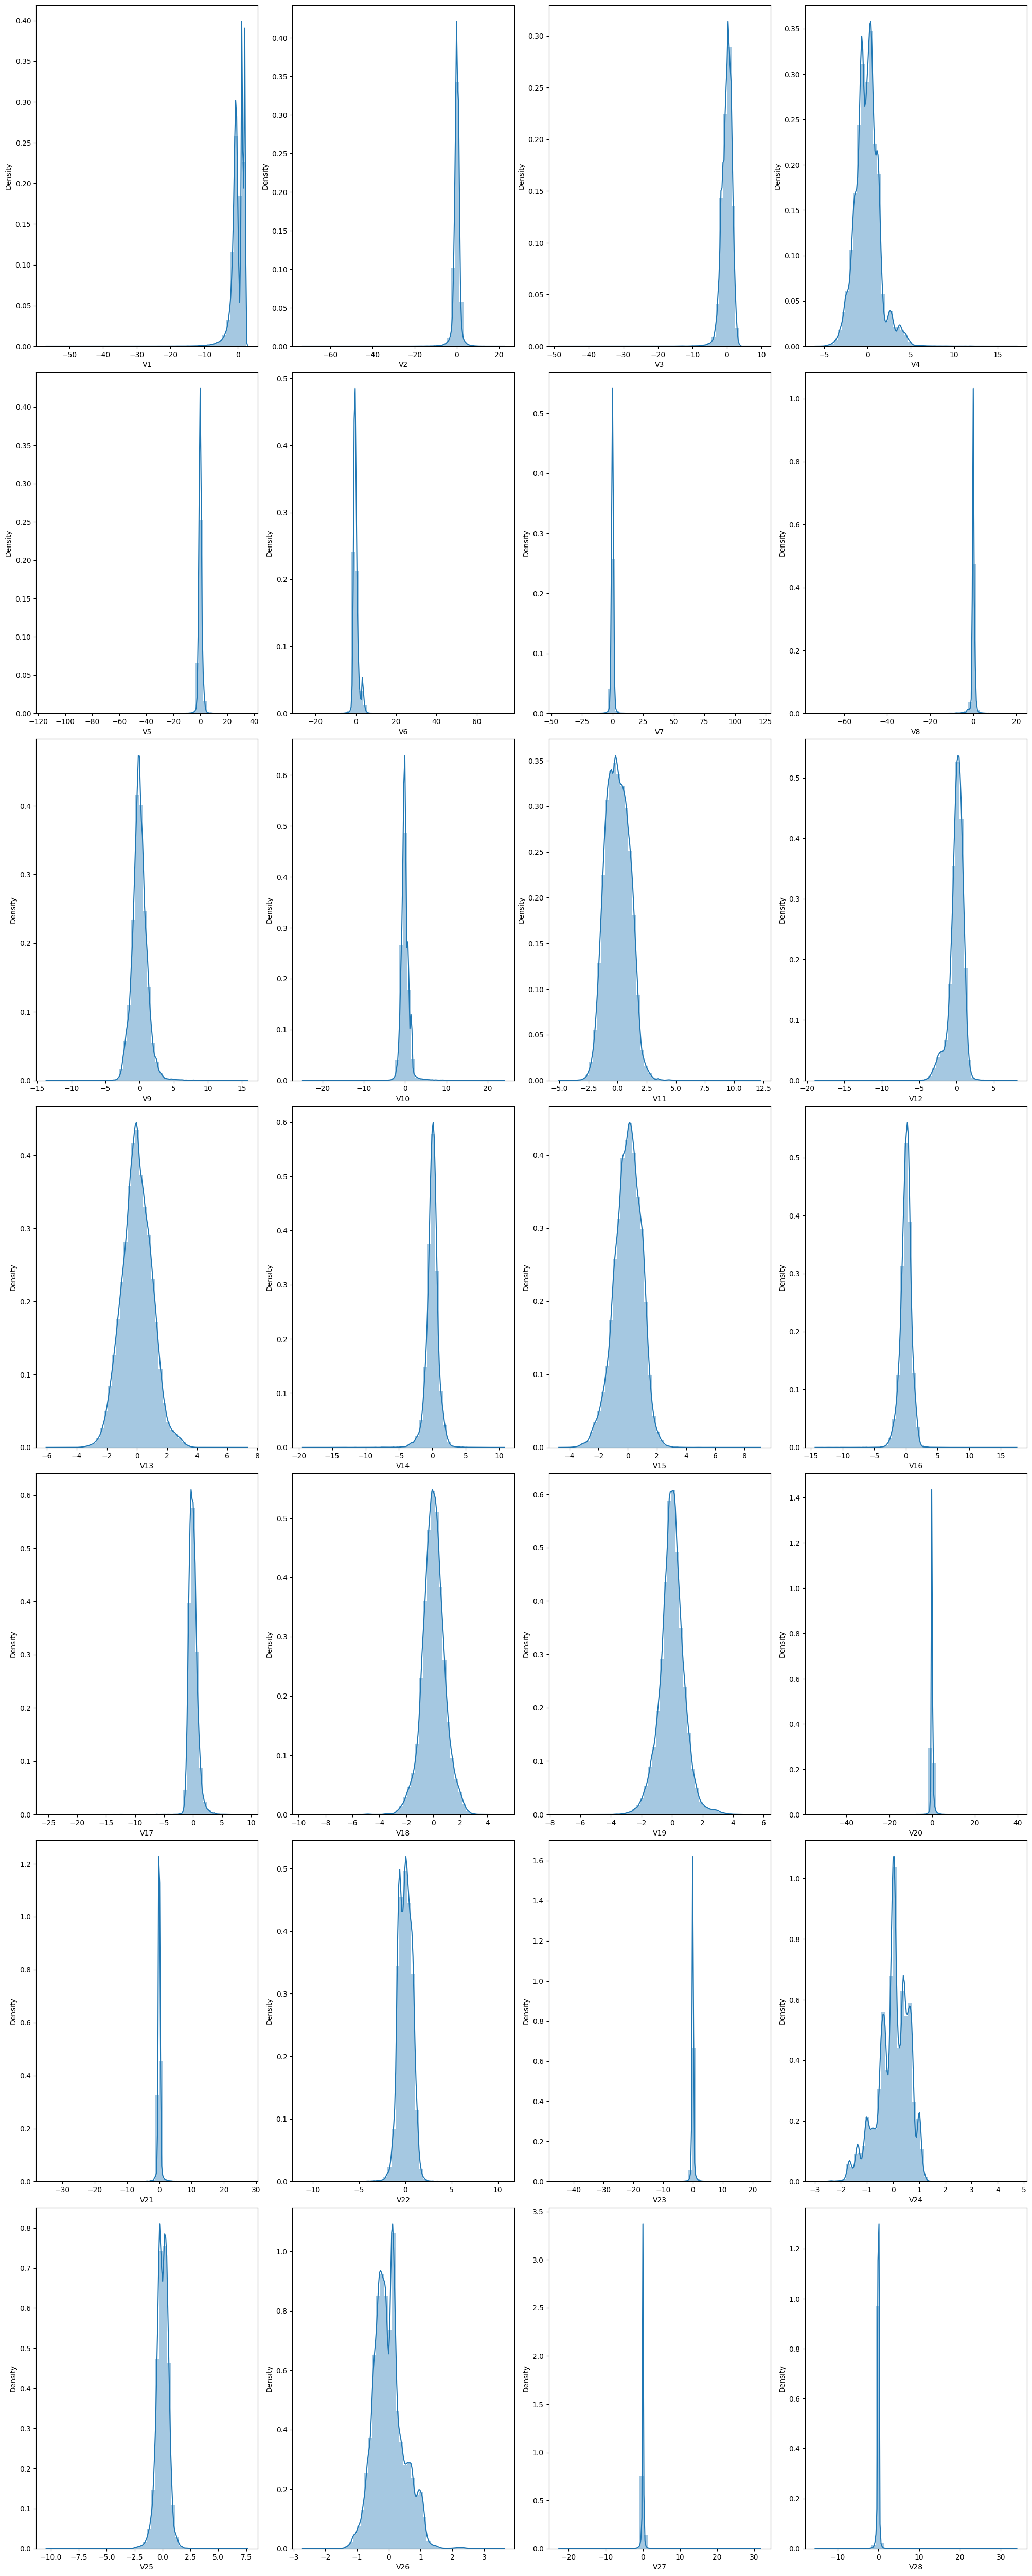

In [29]:
temp = df.drop(columns = ['Class','Time','Amount'],axis = 1)

fig , ax = plt.subplots(ncols = 4,nrows = 7,figsize = (20,50))
index = 0
ax = ax.flatten()

for col in temp.columns:
    sns.distplot(temp[col], ax =ax[index])
    index += 1
plt.tight_layout(pad = 0.5 , w_pad = 0.5,h_pad = 0.5)

<Axes: xlabel='Time', ylabel='Density'>

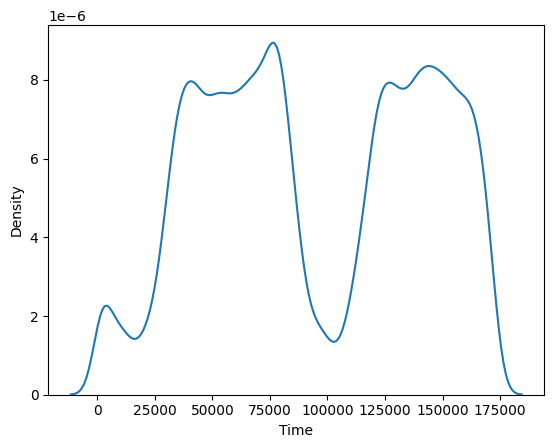

In [30]:
sns.distplot(df['Time'],hist = False)

<Axes: xlabel='Amount', ylabel='Density'>

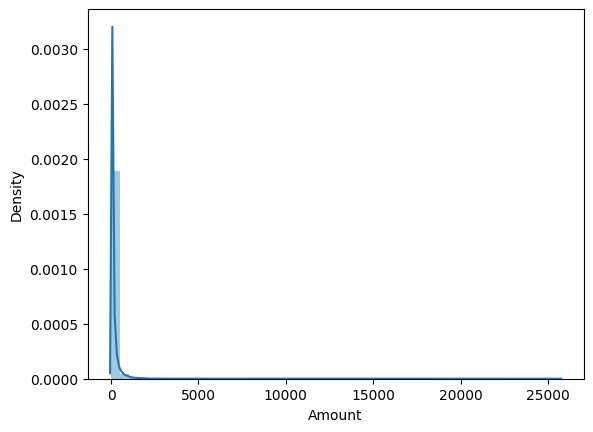

In [31]:
sns.distplot(df['Amount'])

In [32]:
corrr = df.corr()

<Axes: >

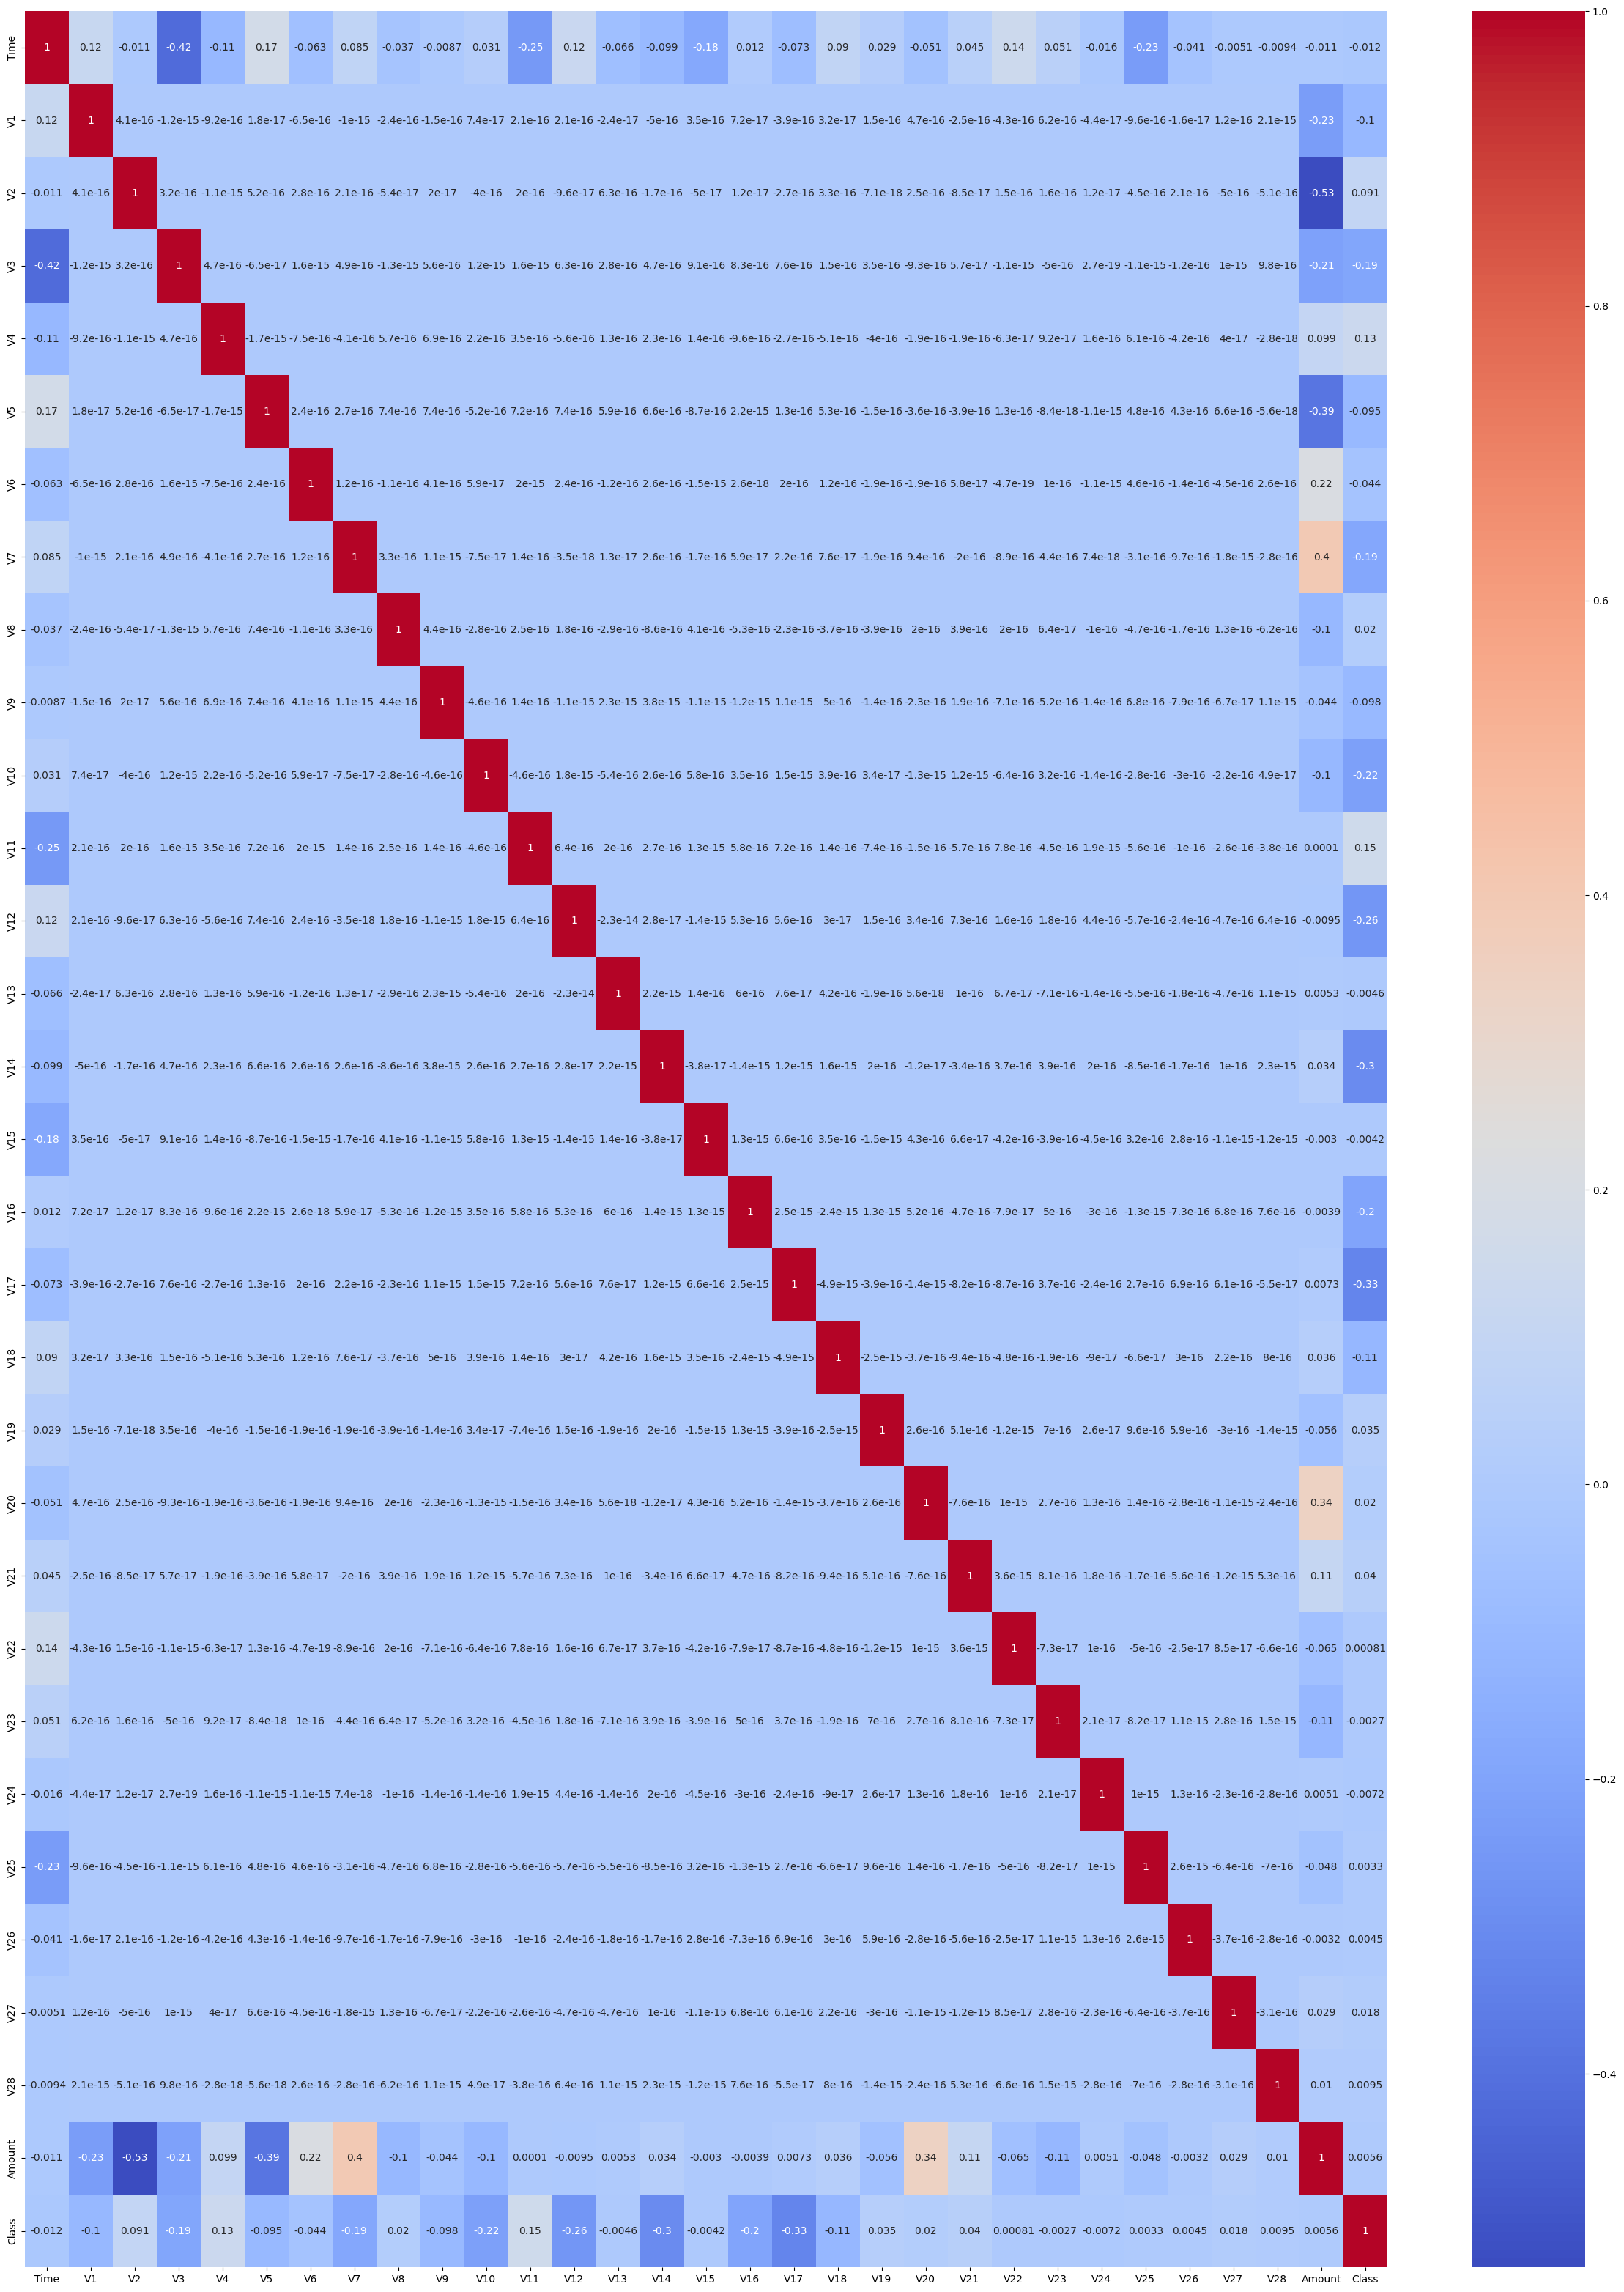

In [33]:
plt.figure(figsize  = (30,40))
sns.heatmap(corrr, annot = True, cmap = 'coolwarm')

<h2>INPUT SPILT<h2>

In [34]:
x = df.drop(columns = ['Class'], axis = 1)

y = df['Class']

<h2>STANDARD SCALING<h2>

In [35]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

In [36]:
standrized_input = sc.fit_transform(x)

In [39]:
standrized_input

array([[-1.99658302, -0.69424232, -0.04407492, ...,  0.33089162,
        -0.06378115,  0.24496426],
       [-1.99658302,  0.60849633,  0.16117592, ..., -0.02225568,
         0.04460752, -0.34247454],
       [-1.99656197, -0.69350046, -0.81157783, ..., -0.13713686,
        -0.18102083,  1.16068593],
       ...,
       [ 1.6419735 ,  0.98002374, -0.18243372, ...,  0.01103672,
        -0.0804672 , -0.0818393 ],
       [ 1.6419735 , -0.12275539,  0.32125034, ...,  0.26960398,
         0.31668678, -0.31324853],
       [ 1.64205773, -0.27233093, -0.11489898, ..., -0.00598394,
         0.04134999,  0.51435531]])

<h2>Model Training</h2>

In [40]:
from sklearn.model_selection import train_test_split
x_tarin, x_test, y_train,y_test = train_test_split(standrized_input,y,test_size= 0.25, random_state=42,stratify = y)

In [44]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

model.fit(x_tarin, y_train) # to train

y_predict = model.predict(x_test) # to predict


In [48]:
# metrics & hyper parameters
from sklearn.metrics import classification_report, confusion_matrix,f1_score

print(classification_report(y_test,y_predict))

print(f1_score(y_test,y_predict))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     71079
           1       0.84      0.62      0.71       123

    accuracy                           1.00     71202
   macro avg       0.92      0.81      0.85     71202
weighted avg       1.00      1.00      1.00     71202

0.7102803738317757


<h2>DOING WITH RADNDOM FOREST</h2>

In [52]:
from sklearn.ensemble import RandomForestClassifier

model1 = RandomForestClassifier()

model1.fit(x_tarin,y_train)  #train the model

RandomForestClassifier()